Практическая работа №2
Решение трансцендентных и алгебраических уравнений методом половинного деления

In [1]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import math

# Настройка отображения графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

Задание 1. Отделение корней графическим методом


Интервалы, где функция меняет знак:
------------------------------------------------------------
[1.377, 1.378] -> f(1.377) = -0.000, f(1.378) = 0.002


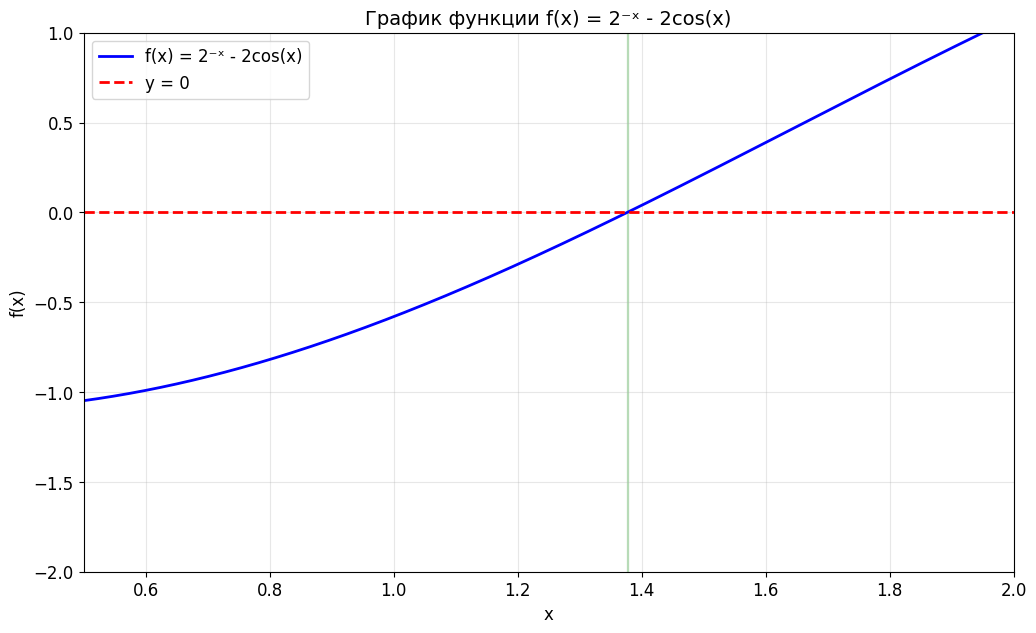


Найденные интервалы с корнями:
Корень 1: x ∈ [1.377, 1.378]

Для уточнения выбираем интервал [1.377, 1.378]


In [2]:
def f2(x):
    """Исходная функция для работы №2"""
    return 2**(-x) - 2 * np.cos(x)

# Создаем массив значений x
x_vals = np.linspace(0.5, 2.0, 1000)
y_vals = f2(x_vals)

# Построение графика
plt.figure(figsize=(12, 7))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = 2⁻ˣ - 2cos(x)')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2, label='y = 0')
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('График функции f(x) = 2⁻ˣ - 2cos(x)', fontsize=14)
plt.legend(fontsize=12)
plt.xlim(0.5, 2.0)
plt.ylim(-2, 1)

# Находим интервалы, где функция меняет знак
intervals = []
print("Интервалы, где функция меняет знак:")
print("-" * 60)

for i in range(len(x_vals)-1):
    if y_vals[i] * y_vals[i+1] < 0:
        a, b = x_vals[i], x_vals[i+1]
        intervals.append((a, b))
        plt.axvspan(a, b, alpha=0.2, color='green')
        print(f"[{a:.3f}, {b:.3f}] -> f({a:.3f}) = {y_vals[i]:.3f}, f({b:.3f}) = {y_vals[i+1]:.3f}")

plt.show()

print("\nНайденные интервалы с корнями:")
for i, (a, b) in enumerate(intervals, 1):
    print(f"Корень {i}: x ∈ [{a:.3f}, {b:.3f}]")

# Выбираем интервал для дальнейшего уточнения
a0, b0 = intervals[0]
print(f"\nДля уточнения выбираем интервал [{a0:.3f}, {b0:.3f}]")

Задание 2. Уточнение корня методом половинного деления с точностью ε

Метод половинного деления (бисекции):

Делим отрезок [a, b] пополам точкой c = (a+b)/2

Определяем, на каком из полученных отрезков [a, c] или [c, b] функция меняет знак

Продолжаем процесс до достижения требуемой точности: (b-a)/2 < ε

In [6]:
def f(x):
    """Исходная функция."""
    return 2**x - 2 * np.cos(x)

def bisection_method(a, b, eps):
    """
    Находит корень уравнения f(x)=0 на отрезке [a, b]
    методом половинного деления с точностью eps.
    """
    if f(a) * f(b) >= 0:
        print(f"Ошибка: f({a}) = {f(a):.4f} и f({b}) = {f(b):.4f} имеют одинаковые знаки.")
        return None

    print("Таблица итераций метода половинного деления:")
    print("┌─────┬───────────┬───────────┬───────────┬───────────┬───────────┐")
    print("│  n  │     a     │     b     │     c     │   f(c)    │  (b-a)/2  │")
    print("├─────┼───────────┼───────────┼───────────┼───────────┼───────────┤")

    iteration = 0
    while (b - a) / 2 > eps:
        c = (a + b) / 2
        fc = f(c)

        print(f"│ {iteration:3d} │ {a:9.6f} │ {b:9.6f} │ {c:9.6f} │ {fc:9.6f} │ {(b-a)/2:9.6f} │")

        if f(a) * fc < 0:
            b = c
        else:
            a = c
        iteration += 1

    c_final = (a + b) / 2
    print("└─────┴───────────┴───────────┴───────────┴───────────┴───────────┘")
    print(f"\nРезультат:")
    print(f"Корень x = {c_final:.6f}")
    print(f"Значение функции f(x) = {f(c_final):.6f}")
    print(f"Число итераций: {iteration}")
    print(f"Достигнутая точность: {(b-a)/2:.6f}")
    return c_final

# Запуск метода на корректном интервале
a_init, b_init = 0.0, 1.5
eps = 0.001
root_bisection = bisection_method(a_init, b_init, eps)

Таблица итераций метода половинного деления:
┌─────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│  n  │     a     │     b     │     c     │   f(c)    │  (b-a)/2  │
├─────┼───────────┼───────────┼───────────┼───────────┼───────────┤
│   0 │  0.000000 │  1.500000 │  0.750000 │  0.218415 │  0.750000 │
│   1 │  0.000000 │  0.750000 │  0.375000 │ -0.564176 │  0.375000 │
│   2 │  0.375000 │  0.750000 │  0.562500 │ -0.215023 │  0.187500 │
│   3 │  0.562500 │  0.750000 │  0.656250 │ -0.008591 │  0.093750 │
│   4 │  0.656250 │  0.750000 │  0.703125 │  0.102377 │  0.046875 │
│   5 │  0.656250 │  0.703125 │  0.679688 │  0.046254 │  0.023438 │
│   6 │  0.656250 │  0.679688 │  0.667969 │  0.018672 │  0.011719 │
│   7 │  0.656250 │  0.667969 │  0.662109 │  0.005000 │  0.005859 │
│   8 │  0.656250 │  0.662109 │  0.659180 │ -0.001805 │  0.002930 │
│   9 │  0.659180 │  0.662109 │  0.660645 │  0.001595 │  0.001465 │
└─────┴───────────┴───────────┴───────────┴───────────┴───────────┘

Ре